# Lección 0.2 · Biopython y herramientas bioinformáticas en Colab

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-00-preparacion/0.2_biopython_herramientas.ipynb) [![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Licencia: MIT](https://img.shields.io/badge/Licencia-MIT-2a78d6.svg)](https://github.com/juvenalyosa/bioinformatica-practica/blob/main/LICENSE)

**Módulo 0 — Preparación del laboratorio digital** · Bioinformática Práctica (Maestría)

👤 **Juvenal Yosa, PhD** · ✉️ [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · 🤖 Copiloto: **Claude** (Anthropic)

| ⏱️ Duración | 📶 Nivel | 🧰 Requisitos |
|---|---|---|
| ~3 horas | Introductorio–intermedio | Lección 0.1 |

---

## 🎯 Objetivos de aprendizaje

1. **Manipular** secuencias con los objetos `Seq` y `SeqRecord` de Biopython (complemento, transcripción, traducción).
2. **Explicar** la lógica combinatoria del código genético y leerlo en una tabla profesional.
3. **Descargar** un genoma real del NCBI con `Entrez` y **explorar** sus anotaciones (genes, CDS, proteínas).
4. **Verificar** computacionalmente las anotaciones de un genoma (¡y descubrir un *frameshift* ribosomal!).
5. **Instalar y ejecutar** herramientas de línea de comandos en Colab (BLAST+) y leer sus resultados con `pandas`.

## 🗺️ Mapa de la clase

1. La caja de herramientas: Biopython y la línea de comandos
2. El objeto `Seq`: del ADN a la proteína
3. El código genético: ¿por qué tripletes? (tabla, rueda interactiva y 🎬 el ribosoma en acción)
4. Los seis marcos de lectura
5. `SeqRecord` y `SeqIO`: leer y escribir archivos
6. 🧪 Experimento: el genoma de SARS-CoV-2, descargado del NCBI
7. 🧪 Experimento: BLAST desde la línea de comandos
8. Ejercicios, resumen y lecturas

## 1. La caja de herramientas

En la lección anterior escribimos nosotros mismos funciones para contar bases y calcular el GC. Eso es excelente
para aprender, pero en el trabajo diario no conviene reinventar cada herramienta: sería como fabricar su propia
micropipeta antes de cada experimento. **Biopython** es la gaveta de herramientas de biología molecular ya
calibradas y probadas por miles de usuarios: complemento reverso, traducción con cualquier código genético, lectura
de decenas de formatos de archivo, acceso al NCBI, y mucho más.

Hay un segundo tipo de herramienta: los **programas de línea de comandos** (BLAST, BWA, samtools, SPAdes…). Son los
equipos grandes del laboratorio — el termociclador, el secuenciador —: programas especializados, escritos en C o C++
para ser muy rápidos, que no se usan desde Python sino escribiendo **instrucciones de texto** en una terminal. Un
bioinformático combina ambos mundos: Python para organizar, analizar y graficar; programas de terminal para el
trabajo pesado.

| Herramienta | Qué es | Cómo se usa en Colab | Ejemplo |
|---|---|---|---|
| Paquete de Python | biblioteca que se importa | `%pip install paquete` y luego `import` | `from Bio.Seq import Seq` |
| Programa de terminal | ejecutable independiente | `!apt-get install programa` y luego `!programa ...` | `!blastn -query q.fasta ...` |

En Colab, cualquier línea que empieza con `!` se envía a la **terminal** (Linux) en lugar de a Python, y `%pip`
instala paquetes de Python. Biopython **no** viene preinstalado en Colab:

In [1]:
# ⚙️ Configuración del entorno (ejecute esta celda primero)
# Bioinformática Práctica · Juvenal Yosa, PhD · Copiloto: Claude
import os, sys, urllib.request

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Descarga el estilo gráfico del curso (en Colab) o lo toma del repositorio (local)
STYLE_URL = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/utils/estilo_curso.py"
if os.path.exists("../utils/estilo_curso.py"):
    sys.path.insert(0, "../utils")
elif not os.path.exists("estilo_curso.py"):
    urllib.request.urlretrieve(STYLE_URL, "estilo_curso.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import estilo_curso as ec

ec.set_style()
print("Entorno listo ✔  |  Colab:", IN_COLAB)

try:
    import Bio
except ImportError:
    %pip install -q biopython
    import Bio
print("Biopython", Bio.__version__)

Entorno listo ✔  |  Colab: False
Biopython 1.88


## 2. El objeto `Seq`: del ADN a la proteína

Un `Seq` se parece a un `str`, pero "sabe biología": conoce el complemento de cada base, sabe transcribir (cambiar
T por U) y conoce el código genético para traducir. Antes de ejecutar, hagamos a mano las primeras operaciones sobre
el inicio del gen de ejemplo, `ATGGCC`:

| Operación | Regla | Resultado a mano |
|---|---|---|
| Complemento | A↔T, C↔G, base por base | `TACCGG` |
| Complemento reverso | complementar y leer al revés | `GGCCAT` |
| Transcripción | T → U (la hebra codificante "se vuelve" ARN) | `AUGGCC` |
| Traducción | leer de a tres: `AUG` = Met (M), `GCC` = Ala (A) | `MA` |

Ahora compruebe que Biopython da lo mismo para la secuencia completa:

In [2]:
from Bio.Seq import Seq

gene = Seq("ATGGCCATTGTAATGGGCCGCTGAAAGGGTGCCCGATAG")

print("ADN (5'→3')           :", gene)
print("Complemento           :", gene.complement())
print("Complemento reverso   :", gene.reverse_complement())
print("ARNm (transcripción)  :", gene.transcribe())
print("Proteína (traducción) :", gene.translate())
print("Proteína hasta el stop:", gene.translate(to_stop=True))

ADN (5'→3')           : ATGGCCATTGTAATGGGCCGCTGAAAGGGTGCCCGATAG
Complemento           : TACCGGTAACATTACCCGGCGACTTTCCCACGGGCTATC
Complemento reverso   : CTATCGGGCACCCTTTCAGCGGCCCATTACAATGGCCAT
ARNm (transcripción)  : AUGGCCAUUGUAAUGGGCCGCUGAAAGGGUGCCCGAUAG
Proteína (traducción) : MAIVMGR*KGAR*
Proteína hasta el stop: MAIVMGR


> 🔎 Observe el `*` en la traducción: representa un **codón de parada** (`TGA`, `TAA`, `TAG`). Con `to_stop=True`
> la traducción se detiene ahí, como lo hace el ribosoma.

**¿Por qué el complemento *reverso*?** Las dos hebras del ADN son **antiparalelas**: una corre 5'→3' y la otra
3'→5'. Por convención siempre escribimos 5'→3', así que para leer la hebra opuesta debemos complementar **y**
invertir el orden.

```
5'-ATGGCC-3'     hebra que leemos
3'-TACCGG-5'     hebra complementaria (tal como está pareada)
5'-GGCCAT-3'     la misma hebra complementaria, escrita 5'→3' = complemento reverso
```

## 3. El código genético: ¿por qué tripletes?

Imagine que debe inventar un idioma con sólo 4 letras (`A`, `C`, `G`, `U`) que sea capaz de nombrar **20
aminoácidos** distintos más una señal de "fin de la frase". Si cada palabra tuviera una sola letra, sólo podría
nombrar 4 cosas. Con palabras de dos letras (`AA`, `AC`, `AG`, …) tendría $4 \times 4 = 16$: todavía no alcanza.
Con tres letras, $4 \times 4 \times 4 = 64$: ahora sobran palabras. La célula resolvió el problema exactamente así.

Si cada "palabra" (codón) tiene $L$ letras de un alfabeto de 4, el número de palabras posibles es:

$$
N(L) \;=\; \underbrace{4}_{\text{bases}}{}^{\overbrace{L}^{\text{longitud del codón}}}
\qquad\Longrightarrow\qquad
N(1) = 4,\quad N(2) = 16 \;<\; 21 \;\le\; N(3) = 64
$$

Con dos letras no alcanza (16 < 21); con tres sobran palabras (64). Por eso el código es **degenerado**
(redundante): varios codones significan el mismo aminoácido. Por ejemplo, la leucina tiene 6 codones y el
triptófano sólo 1.

La redundancia no es un desperdicio: funciona como un **amortiguador de errores**. Observe en la tabla que los
codones sinónimos casi siempre difieren sólo en la **tercera** base (por ejemplo `GCU`, `GCC`, `GCA`, `GCG` son todos
alanina). Por eso muchas mutaciones en la tercera posición no cambian la proteína: son mutaciones **sinónimas**.
Además, los aminoácidos de propiedades parecidas tienden a tener codones parecidos, así que incluso muchos errores
en la primera posición producen un aminoácido químicamente similar.

**Cómo leer la tabla.** Para el codón `CAU`: busque la fila grande de la **1ª base** (`C`, a la izquierda), la columna
de la **2ª base** (`A`, arriba) y, dentro de ese bloque, la línea de la **3ª base** (`U`, que en ADN se escribe `T`):
histidina (His, H).

Veamos la tabla completa, construida directamente desde Biopython. Los aminoácidos se colorean por su **propiedad
química**, que es lo que realmente importa para la estructura de una proteína:

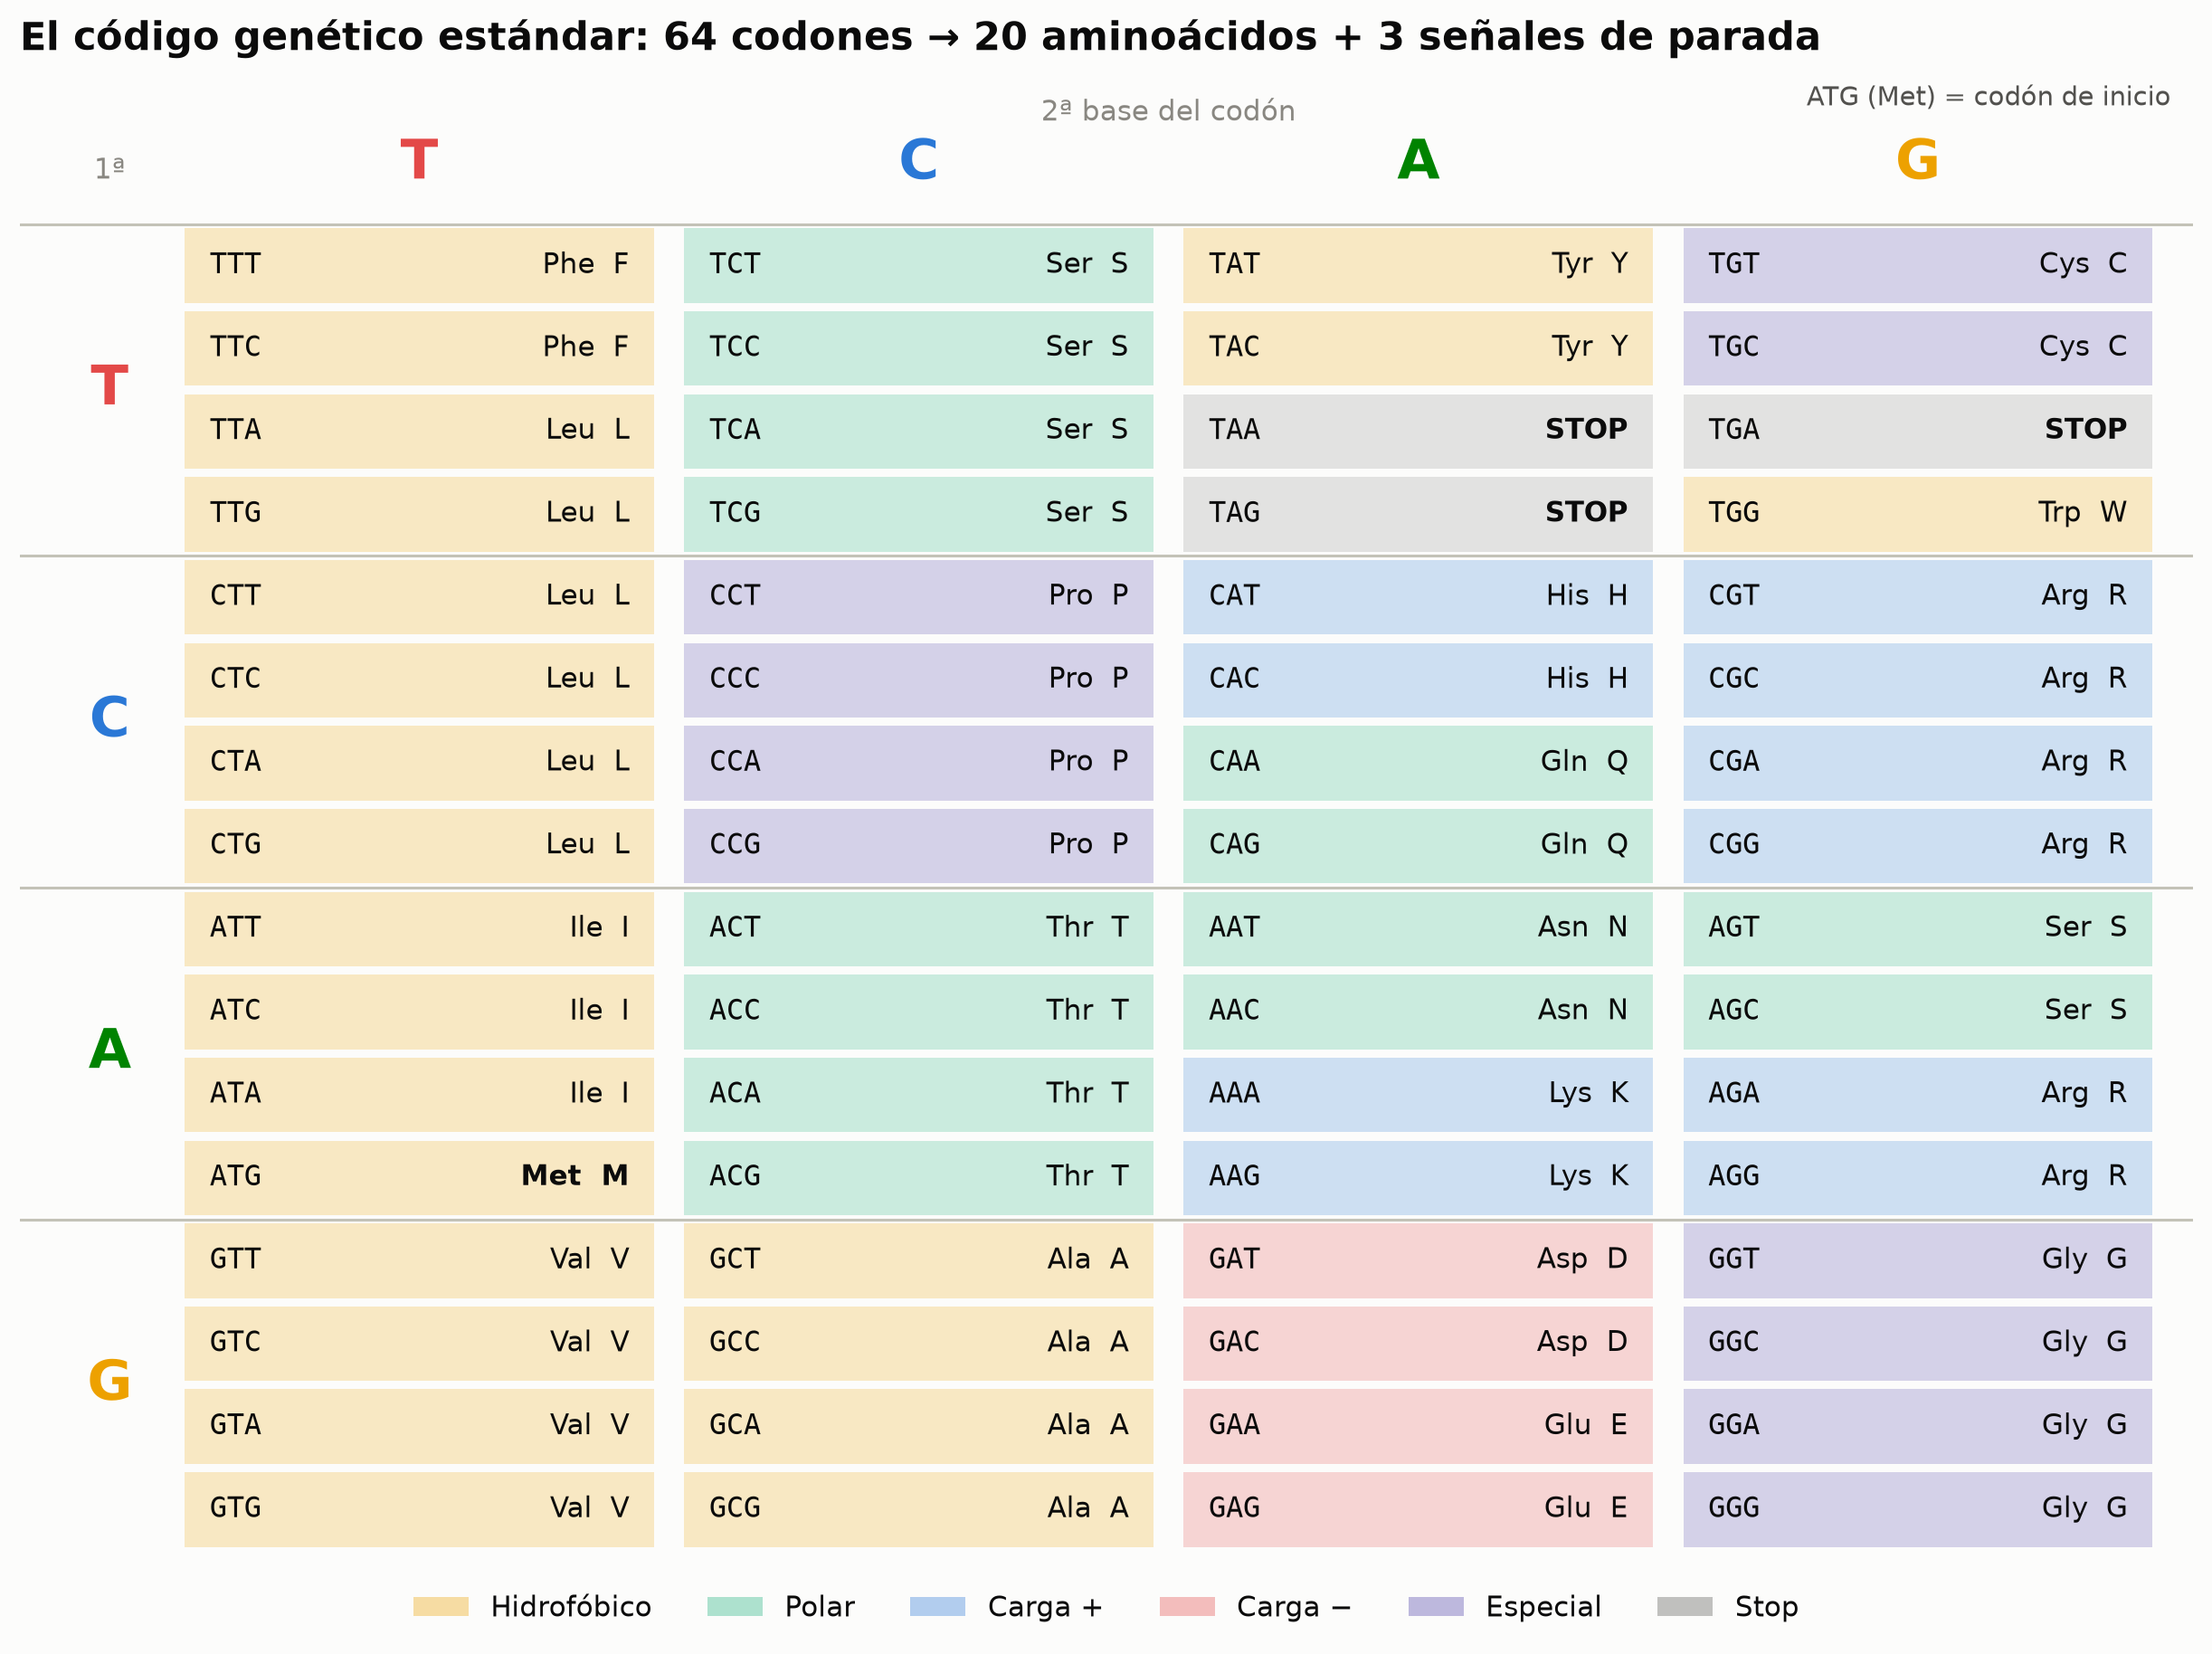

In [3]:
from Bio.Data import CodonTable

table = CodonTable.unambiguous_dna_by_id[1]          # código genético estándar (NCBI tabla 1)
aa_class = {                                          # clases fisicoquímicas
    **{a: "Hidrofóbico" for a in "AVILMFWY"},
    **{a: "Polar" for a in "STNQ"},
    **{a: "Carga +" for a in "KRH"},
    **{a: "Carga −" for a in "DE"},
    **{a: "Especial" for a in "GPC"},
    "*": "Stop",
}
class_color = {"Hidrofóbico": ec.YELLOW, "Polar": ec.AQUA, "Carga +": ec.BLUE,
               "Carga −": ec.RED, "Especial": ec.VIOLET, "Stop": ec.INK_2}
three = {"A":"Ala","R":"Arg","N":"Asn","D":"Asp","C":"Cys","Q":"Gln","E":"Glu","G":"Gly","H":"His","I":"Ile",
         "L":"Leu","K":"Lys","M":"Met","F":"Phe","P":"Pro","S":"Ser","T":"Thr","W":"Trp","Y":"Tyr","V":"Val","*":"Stop"}

bases = "TCAG"
fig, ax = plt.subplots(figsize=(11, 8.2))
for i, b1 in enumerate(bases):
    for j, b2 in enumerate(bases):
        for k, b3 in enumerate(bases):
            codon = b1 + b2 + b3
            aa = "*" if codon in table.stop_codons else table.forward_table[codon]
            x, y = j, -(i * 4 + k)
            ax.add_patch(plt.Rectangle((x + 0.03, y - 0.45), 0.94, 0.9, color=class_color[aa_class[aa]],
                                       alpha=0.22 if aa != "*" else 0.15, lw=0))
            ax.text(x + 0.08, y, codon, va="center", fontsize=10.5, family="DejaVu Sans Mono", color=ec.INK)
            label = f"{three[aa]}  {aa}" if aa != "*" else "STOP"
            weight = "bold" if codon == "ATG" or aa == "*" else "normal"
            ax.text(x + 0.92, y, label, va="center", ha="right", fontsize=10, color=ec.INK, fontweight=weight)
    ax.axhline(-(i * 4) + 0.5, color=ec.BASELINE, lw=1)
    ax.text(-0.12, -(i * 4 + 1.5), b1, fontsize=20, fontweight="bold", ha="center", va="center",
            color=ec.NUC_COLORS[b1])
for j, b2 in enumerate(bases):
    ax.text(j + 0.5, 1.05, b2, fontsize=20, fontweight="bold", ha="center", color=ec.NUC_COLORS[b2])
ax.text(-0.12, 1.05, "1ª", ha="center", color=ec.MUTED, fontsize=10)
ax.text(2.0, 1.75, "2ª base del codón", ha="center", color=ec.MUTED, fontsize=10)
ax.set_xlim(-0.3, 4.05); ax.set_ylim(-15.6, 2.2); ax.axis("off")
handles = [plt.Rectangle((0, 0), 1, 1, color=c, alpha=0.35) for c in class_color.values()]
ax.legend(handles, class_color.keys(), ncol=6, loc="lower center", bbox_to_anchor=(0.5, -0.06))
ax.set_title("El código genético estándar: 64 codones → 20 aminoácidos + 3 señales de parada", loc="left")
ax.text(0.99, 0.985, "ATG (Met) = codón de inicio", transform=ax.transAxes, ha="right", fontsize=9.5, color=ec.INK_2)
plt.show()

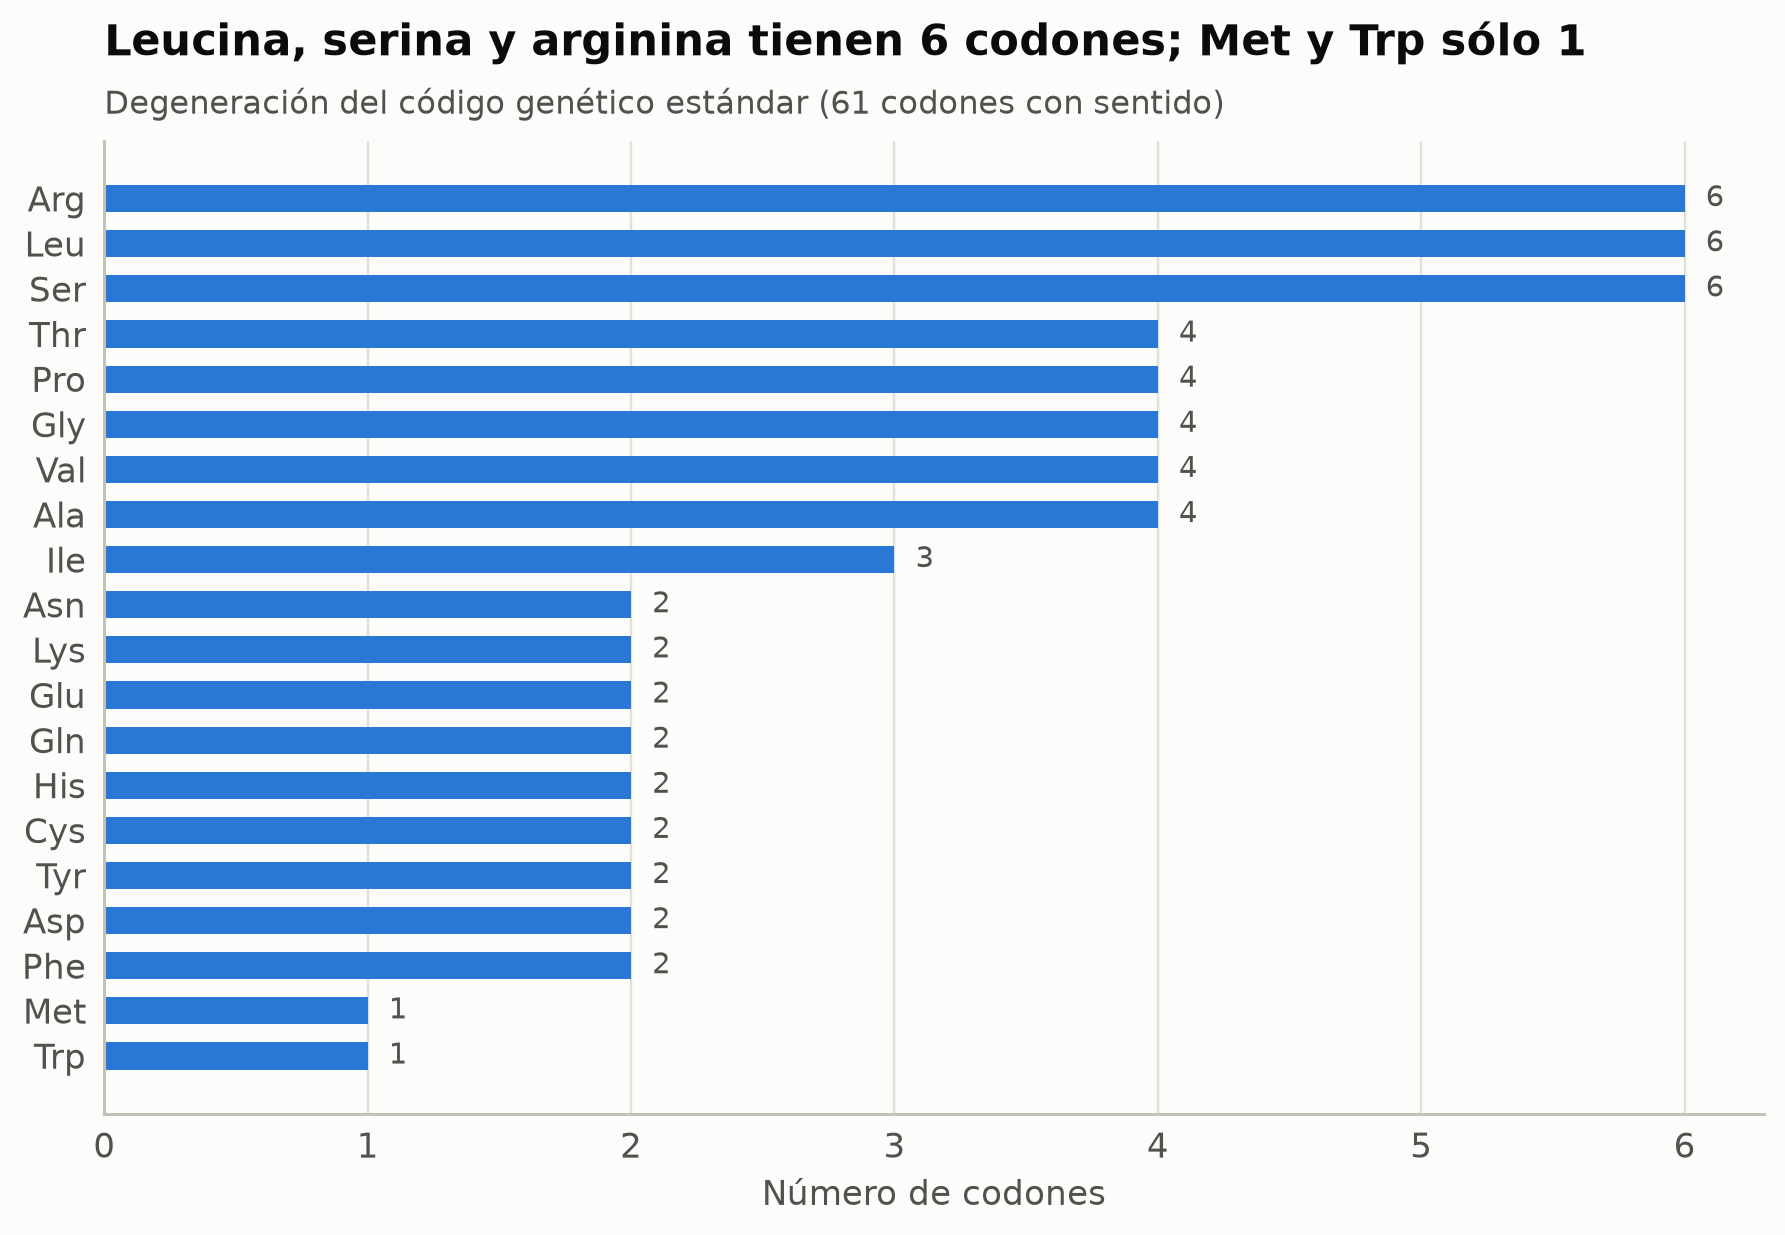

In [4]:
# ¿Cuán degenerado es el código? Contamos codones por aminoácido
from collections import Counter
degeneracy = Counter(table.forward_table.values())
deg = (pd.Series(degeneracy).rename(index=three).sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(deg.index, deg.values, color=ec.BLUE, height=0.6)
for y, v in enumerate(deg.values):
    ax.text(v + 0.08, y, str(v), va="center", color=ec.INK_2, fontsize=9.5)
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
ax.set_xlabel("Número de codones")
ec.title(ax, "Leucina, serina y arginina tienen 6 codones; Met y Trp sólo 1",
         "Degeneración del código genético estándar (61 codones con sentido)")
plt.show()

### 🖱️ La rueda del código genético (interactiva)

Muchos libros de texto muestran el código genético como una **rueda**: se lee desde el centro hacia afuera
(1ª base → 2ª base → 3ª base) y en el borde aparece el aminoácido. Haga **clic** en un sector para acercarse (por
ejemplo, en `G` del centro para ver sólo los codones que empiezan con G) y clic en el centro para volver.
Pase el cursor sobre cada codón para ver su aminoácido y su clase química.

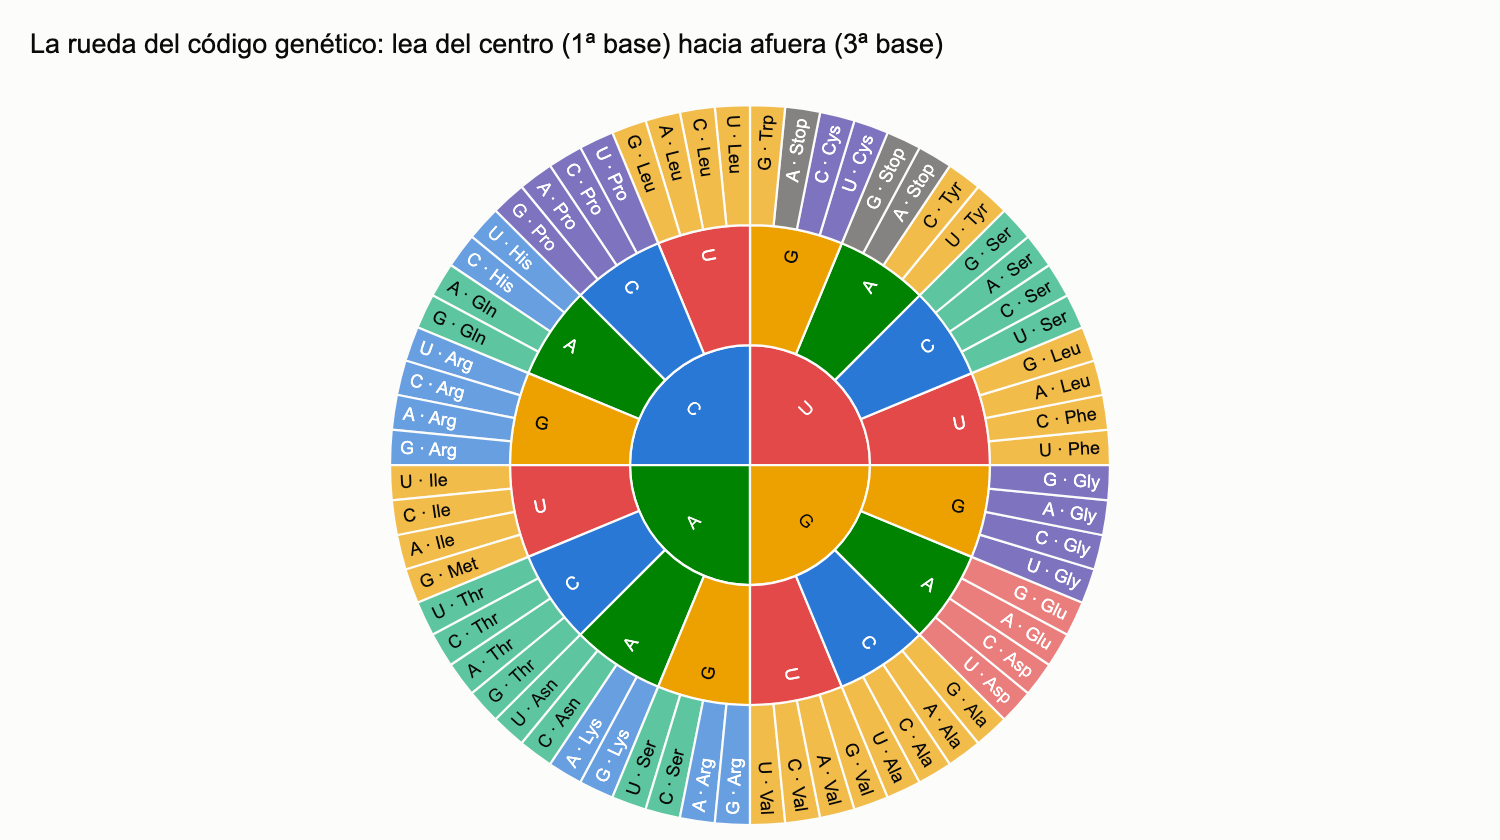

In [5]:
import plotly.express as px
import plotly.graph_objects as go

rna = lambda s: s.replace("T", "U")
ids, labels, parents, colors, hovers = [], [], [], [], []
for b1 in "UCAG":
    ids.append(b1); labels.append(b1); parents.append(""); colors.append(ec.NUC_COLORS[b1])
    hovers.append(f"1ª base: {b1}")
    for b2 in "UCAG":
        ids.append(b1 + b2); labels.append(b2); parents.append(b1); colors.append(ec.NUC_COLORS[b2])
        hovers.append(f"Codones {b1}{b2}_")
        for b3 in "UCAG":
            dna_codon = (b1 + b2 + b3).replace("U", "T")
            aa = "*" if dna_codon in table.stop_codons else table.forward_table[dna_codon]
            ids.append(b1 + b2 + b3)
            labels.append(f"{b3} · {three[aa] if aa != '*' else 'Stop'}")
            parents.append(b1 + b2)
            colors.append(class_color[aa_class[aa]])
            hovers.append(f"Codón {b1}{b2}{b3} → {three[aa]} ({aa})<br>Clase: {aa_class[aa]}")
fig = go.Figure(go.Sunburst(ids=ids, labels=labels, parents=parents, marker=dict(colors=colors,
                line=dict(color=ec.SURFACE, width=1.5)), hovertext=hovers, hoverinfo="text",
                insidetextorientation="radial",
                textfont=dict(size=12, color=[ec.INK if c in (ec.YELLOW, ec.AQUA, ec.NUC_COLORS["G"]) else "white"
                                              for c in colors])))
fig.update_layout(title="La rueda del código genético: lea del centro (1ª base) hacia afuera (3ª base)",
                  height=680, margin=dict(t=70, l=10, r=10, b=10))
fig.show()

> ✅ **Compruebe su comprensión.** (1) Use la rueda para encontrar los tres codones de parada. ¿Qué tienen en común?
> (2) ¿Cuántos codones de glicina hay y en qué posición difieren? (3) Una mutación cambia `GCU` por `GCA`. ¿Cambia la
> proteína?

### 🎬 El ribosoma en acción

La traducción es un proceso **secuencial**: el ribosoma se sienta sobre el ARNm, lee **un codón**, trae el
aminoácido correspondiente (lo acarrea un ARN de transferencia), lo une a la cadena que va creciendo y avanza
**exactamente tres bases**. Repite hasta encontrar un codón de parada, y entonces suelta la proteína. La animación
muestra ese ciclo con el gen de ejemplo.

![Vista previa: el ribosoma lee el ARNm de tres en tres y la cadena de aminoácidos crece hasta el codón de parada.](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-00-preparacion/0.2_ribosoma.gif)

*Vista previa: el ribosoma lee el ARNm de tres en tres y la cadena de aminoácidos crece hasta el codón de parada.*

In [6]:
from matplotlib.patches import FancyBboxPatch, Circle

mrna = str(gene.transcribe())[:24]                        # 8 codones: AUG GCC AUU GUA AUG GGC CGC UGA
codons = [mrna[i:i + 3] for i in range(0, len(mrna), 3)]
aas = [table.forward_table.get(c.replace("U", "T"), "*") for c in codons]

fig, ax = plt.subplots(figsize=(11, 3.0))
ax.set_xlim(-1, len(mrna) + 1); ax.set_ylim(-1.6, 3.0); ax.set_aspect("equal"); ax.axis("off")
for i, b in enumerate(mrna):                               # la cadena de ARNm
    ax.add_patch(FancyBboxPatch((i + 0.06, -0.45), 0.88, 0.9, boxstyle="round,pad=0,rounding_size=0.12",
                                color=ec.NUC_COLORS[b], alpha=0.85, lw=0))
    ax.text(i + 0.5, 0, b, ha="center", va="center", color="white", fontsize=12, fontweight="bold")
ax.text(-0.9, 0, "5'", ha="center", va="center", color=ec.INK_2, fontsize=11)
ax.text(len(mrna) + 0.9, 0, "3'", ha="center", va="center", color=ec.INK_2, fontsize=11)
ribo = FancyBboxPatch((0, -0.75), 3, 1.5, boxstyle="round,pad=0.05,rounding_size=0.5",
                      fc=(0.29, 0.23, 0.65, 0.18), ec=ec.VIOLET, lw=2)
ax.add_patch(ribo)
codon_label = ax.text(1.5, -1.25, "", ha="center", va="center", fontsize=11, color=ec.INK)
beads, bead_txt = [], []
for k, aa in enumerate(aas):                              # cuentas de la cadena peptídica (ocultas al inicio)
    color = ec.INK_2 if aa == "*" else class_color[aa_class[aa]]
    if k > 0:                                              # enlace peptídico con el residuo anterior
        bond, = ax.plot([1.5 + 2.2 * (k - 1), 1.5 + 2.2 * k], [2.1, 2.1], color=ec.MUTED, lw=2.5, zorder=1,
                        visible=False)
    c = Circle((1.5 + 2.2 * k, 2.1), 0.62, color=color, visible=False, zorder=2)
    c.bond = bond if k > 0 else None
    ax.add_patch(c); beads.append(c)
    bead_txt.append(ax.text(1.5 + 2.2 * k, 2.1, "STOP" if aa == "*" else three[aa], ha="center", va="center",
                            color="white", fontsize=9, fontweight="bold", visible=False, zorder=3))
title = ax.set_title("", loc="left")

frames_per_codon = 4
n_frames = frames_per_codon * len(codons) + 6

def update(f):
    k = min(f // frames_per_codon, len(codons) - 1)       # codón que se está leyendo
    ribo.set_x(3 * k)
    codon_label.set_position((3 * k + 1.5, -1.25))
    aa = aas[k]
    codon_label.set_text(f"{codons[k]} → {'STOP' if aa == '*' else three[aa]}")
    for j in range(len(codons)):
        beads[j].set_visible(j <= k); bead_txt[j].set_visible(j <= k)
        if beads[j].bond is not None:
            beads[j].bond.set_visible(j <= k)
    if aa == "*":
        title.set_text(f"Codón de parada {codons[k]}: el ribosoma libera la proteína "
                       f"{''.join(a for a in aas if a != '*')}")
    else:
        title.set_text(f"Codón {k + 1}: el ribosoma lee {codons[k]} y añade {three[aa]}")
    return ()

ec.animate(fig, update, frames=n_frames, interval=250, name="0.2_ribosoma")

## 4. Los seis marcos de lectura

Una secuencia de ADN puede leerse en **tres marcos** en cada hebra (empezando en la posición 1, 2 ó 3), es decir
**seis marcos** en total. Sólo uno (o ninguno) corresponde a la proteína real.

Lea esta frase escrita sin espacios: `ELSOLSALEYELGATOSEVA`. Si la corta en las palabras correctas obtiene
`EL SOL SALE Y EL GATO SE VA`. Si empieza a cortar una letra más adelante obtiene `LSO LSA LEY ELG…`: basura.
El ADN tampoco tiene "espacios" entre codones: el **marco de lectura** es la decisión de dónde empezar a cortar de a
tres. Como hay 3 puntos de partida posibles en cada hebra, y dos hebras, existen **6 marcos**.

**Ejemplo a mano.** Para `ATGGCCATT`:

| Marco | Cortes | Traducción |
|---|---|---|
| +1 | `ATG GCC ATT` | M A I |
| +2 | `TGG CCA` (sobra `TT`) | W P |
| +3 | `GGC CAT` (sobra `T`) | G H |

Los marcos −1, −2, −3 se obtienen igual, pero sobre el complemento reverso (`AATGGCCAT`).

In [7]:
def six_frames(seq: Seq) -> dict:
    """Traduce los 6 marcos de lectura (+1, +2, +3 en la hebra directa; −1, −2, −3 en la reversa)."""
    frames = {}
    for strand, s in [("+", seq), ("−", seq.reverse_complement())]:
        for f in range(3):
            sub = s[f:]
            sub = sub[: len(sub) - len(sub) % 3]              # múltiplo de 3
            frames[f"{strand}{f + 1}"] = str(sub.translate())
    return frames

for name, prot in six_frames(gene).items():
    print(f"marco {name}: {prot}")

marco +1: MAIVMGR*KGAR*
marco +2: WPL*WAAERVPD
marco +3: GHCNGPLKGCPI
marco −1: LSGTLSAAHYNGH
marco −2: YRAPFQRPITMA
marco −3: IGHPFSGPLQWP


> 🔎 **Qué observamos.** Un marco "real" suele verse como un tramo **largo sin `*`** que empieza en `M`: un **marco
> abierto de lectura** (ORF). En secuencias al azar aparece un codón de parada cada ~21 codones (3 de 64), así que
> los tramos largos sin `*` son una señal de gen. En la Lección 1.2 construiremos un buscador de ORFs completo.

## 5. `SeqRecord` y `SeqIO`: leer y escribir archivos

Una secuencia sola no basta: necesitamos su **identificador**, **descripción** y **anotaciones**. Eso es un
`SeqRecord`. El módulo `SeqIO` lee y escribe decenas de formatos (FASTA, GenBank, FASTQ…) con la misma interfaz.

El formato más simple es **FASTA**:

```
>identificador descripción opcional        ← línea de encabezado, empieza con ">"
ATGGCCATTGTAATGGGCCGCTGAAAGGGTGCCCGATAG    ← secuencia (puede ocupar varias líneas)
```

In [8]:
from Bio.SeqRecord import SeqRecord
from Bio import SeqIO

records = [
    SeqRecord(gene, id="demo_gene", description="gen de juguete"),
    SeqRecord(gene.reverse_complement(), id="demo_gene_rc", description="complemento reverso"),
]
SeqIO.write(records, "demo.fasta", "fasta")
print(open("demo.fasta").read())

for rec in SeqIO.parse("demo.fasta", "fasta"):
    print(rec.id, "|", len(rec), "pb |", rec.description)

>demo_gene gen de juguete
ATGGCCATTGTAATGGGCCGCTGAAAGGGTGCCCGATAG
>demo_gene_rc complemento reverso
CTATCGGGCACCCTTTCAGCGGCCCATTACAATGGCCAT

demo_gene | 39 pb | demo_gene gen de juguete
demo_gene_rc | 39 pb | demo_gene_rc complemento reverso


## 6. 🧪 Experimento: el genoma de SARS-CoV-2

Vamos a trabajar con un genoma **real**: la secuencia de referencia de SARS-CoV-2 (aislado Wuhan-Hu-1,
`NC_045512.2`), ~30 000 nucleótidos. La descargamos del NCBI con `Entrez`, la interfaz programática de sus bases
de datos.

> ⚠️ El NCBI pide un correo electrónico para identificar a quien hace las consultas. Ponga el suyo.
> Si la descarga falla (sin internet o NCBI saturado), la celda usa una copia guardada en el repositorio del curso.

El formato **GenBank** es mucho más rico que FASTA. Si FASTA es un libro sin índice, GenBank es el libro con índice,
notas al margen y bibliografía: además de la secuencia trae **anotaciones** (*features*) que dicen dónde empieza y
termina cada gen, en qué hebra está, qué proteína produce, quién lo secuenció y en qué artículo se publicó. Un
fragmento típico de la sección de anotaciones se ve así:

```
     CDS             21563..25384
                     /gene="S"
                     /product="surface glycoprotein"
                     /translation="MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS..."
```

Es decir: "entre las posiciones 21 563 y 25 384 hay una secuencia codificante (CDS) del gen S, que produce la
glicoproteína de superficie, cuya secuencia de aminoácidos es…". Biopython convierte todo eso en objetos de Python.

In [9]:
from Bio import Entrez

Entrez.email = "su.correo@ejemplo.com"     # ← escriba aquí su correo
ACCESSION = "NC_045512.2"
BACKUP_URL = ("https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/data/"
              f"{ACCESSION}.gb")
gb_file = f"{ACCESSION}.gb"

if not os.path.exists(gb_file):
    try:
        with Entrez.efetch(db="nuccore", id=ACCESSION, rettype="gbwithparts", retmode="text") as handle:
            open(gb_file, "w").write(handle.read())
        print("Descargado del NCBI ✔")
    except Exception as err:
        print("NCBI no respondió (", err, ") → usando la copia del curso")
        urllib.request.urlretrieve(BACKUP_URL, gb_file)

genome = SeqIO.read(gb_file, "genbank")
print(genome.id, "|", genome.description)
print("Longitud:", f"{len(genome):,}", "nt  |  anotaciones:", len(genome.features))

Descargado del NCBI ✔
NC_045512.2 | Severe acute respiratory syndrome coronavirus 2 isolate Wuhan-Hu-1, complete genome
Longitud: 29,903 nt  |  anotaciones: 57


In [10]:
# Extraemos los genes codificantes (CDS) en una tabla
rows = []
for feat in genome.features:
    if feat.type == "CDS":
        q = feat.qualifiers
        rows.append({
            "gene": q.get("gene", ["?"])[0],
            "start": int(feat.location.start) + 1,          # +1: coordenadas biológicas (1-based)
            "end": int(feat.location.end),
            "strand": "+" if feat.location.strand == 1 else "−",
            "parts": len(feat.location.parts),
            "length_nt": len(feat.location),
            "product": q.get("product", [""])[0],
        })
cds = pd.DataFrame(rows)
cds

,gene,start,end,strand,parts,length_nt,product
0,ORF1ab,266,21555,+,2,21291,ORF1ab polyprotein
1,ORF1ab,266,13483,+,1,13218,ORF1a polyprotein
2,S,21563,25384,+,1,3822,surface glycoprotein
3,ORF3a,25393,26220,+,1,828,ORF3a protein
4,E,26245,26472,+,1,228,envelope protein
5,M,26523,27191,+,1,669,membrane glycoprotein
6,ORF6,27202,27387,+,1,186,ORF6 protein
7,ORF7a,27394,27759,+,1,366,ORF7a protein
8,ORF7b,27756,27887,+,1,132,ORF7b
9,ORF8,27894,28259,+,1,366,ORF8 protein


> 🔎 Hay **dos** entradas con el gen `ORF1ab`: la poliproteína larga **pp1ab**, que tiene **2 partes**
> (`parts = 2`), y la corta **pp1a**. Guarde esa pista; la resolvemos en un momento.

### Mapa del genoma

Un buen mapa genómico combina la **posición de los genes** (flechas en la dirección de transcripción) con una
**medida a lo largo de la secuencia** (aquí el contenido GC en ventanas de 500 nt, que ya sabe interpretar gracias a
la Lección 0.1).

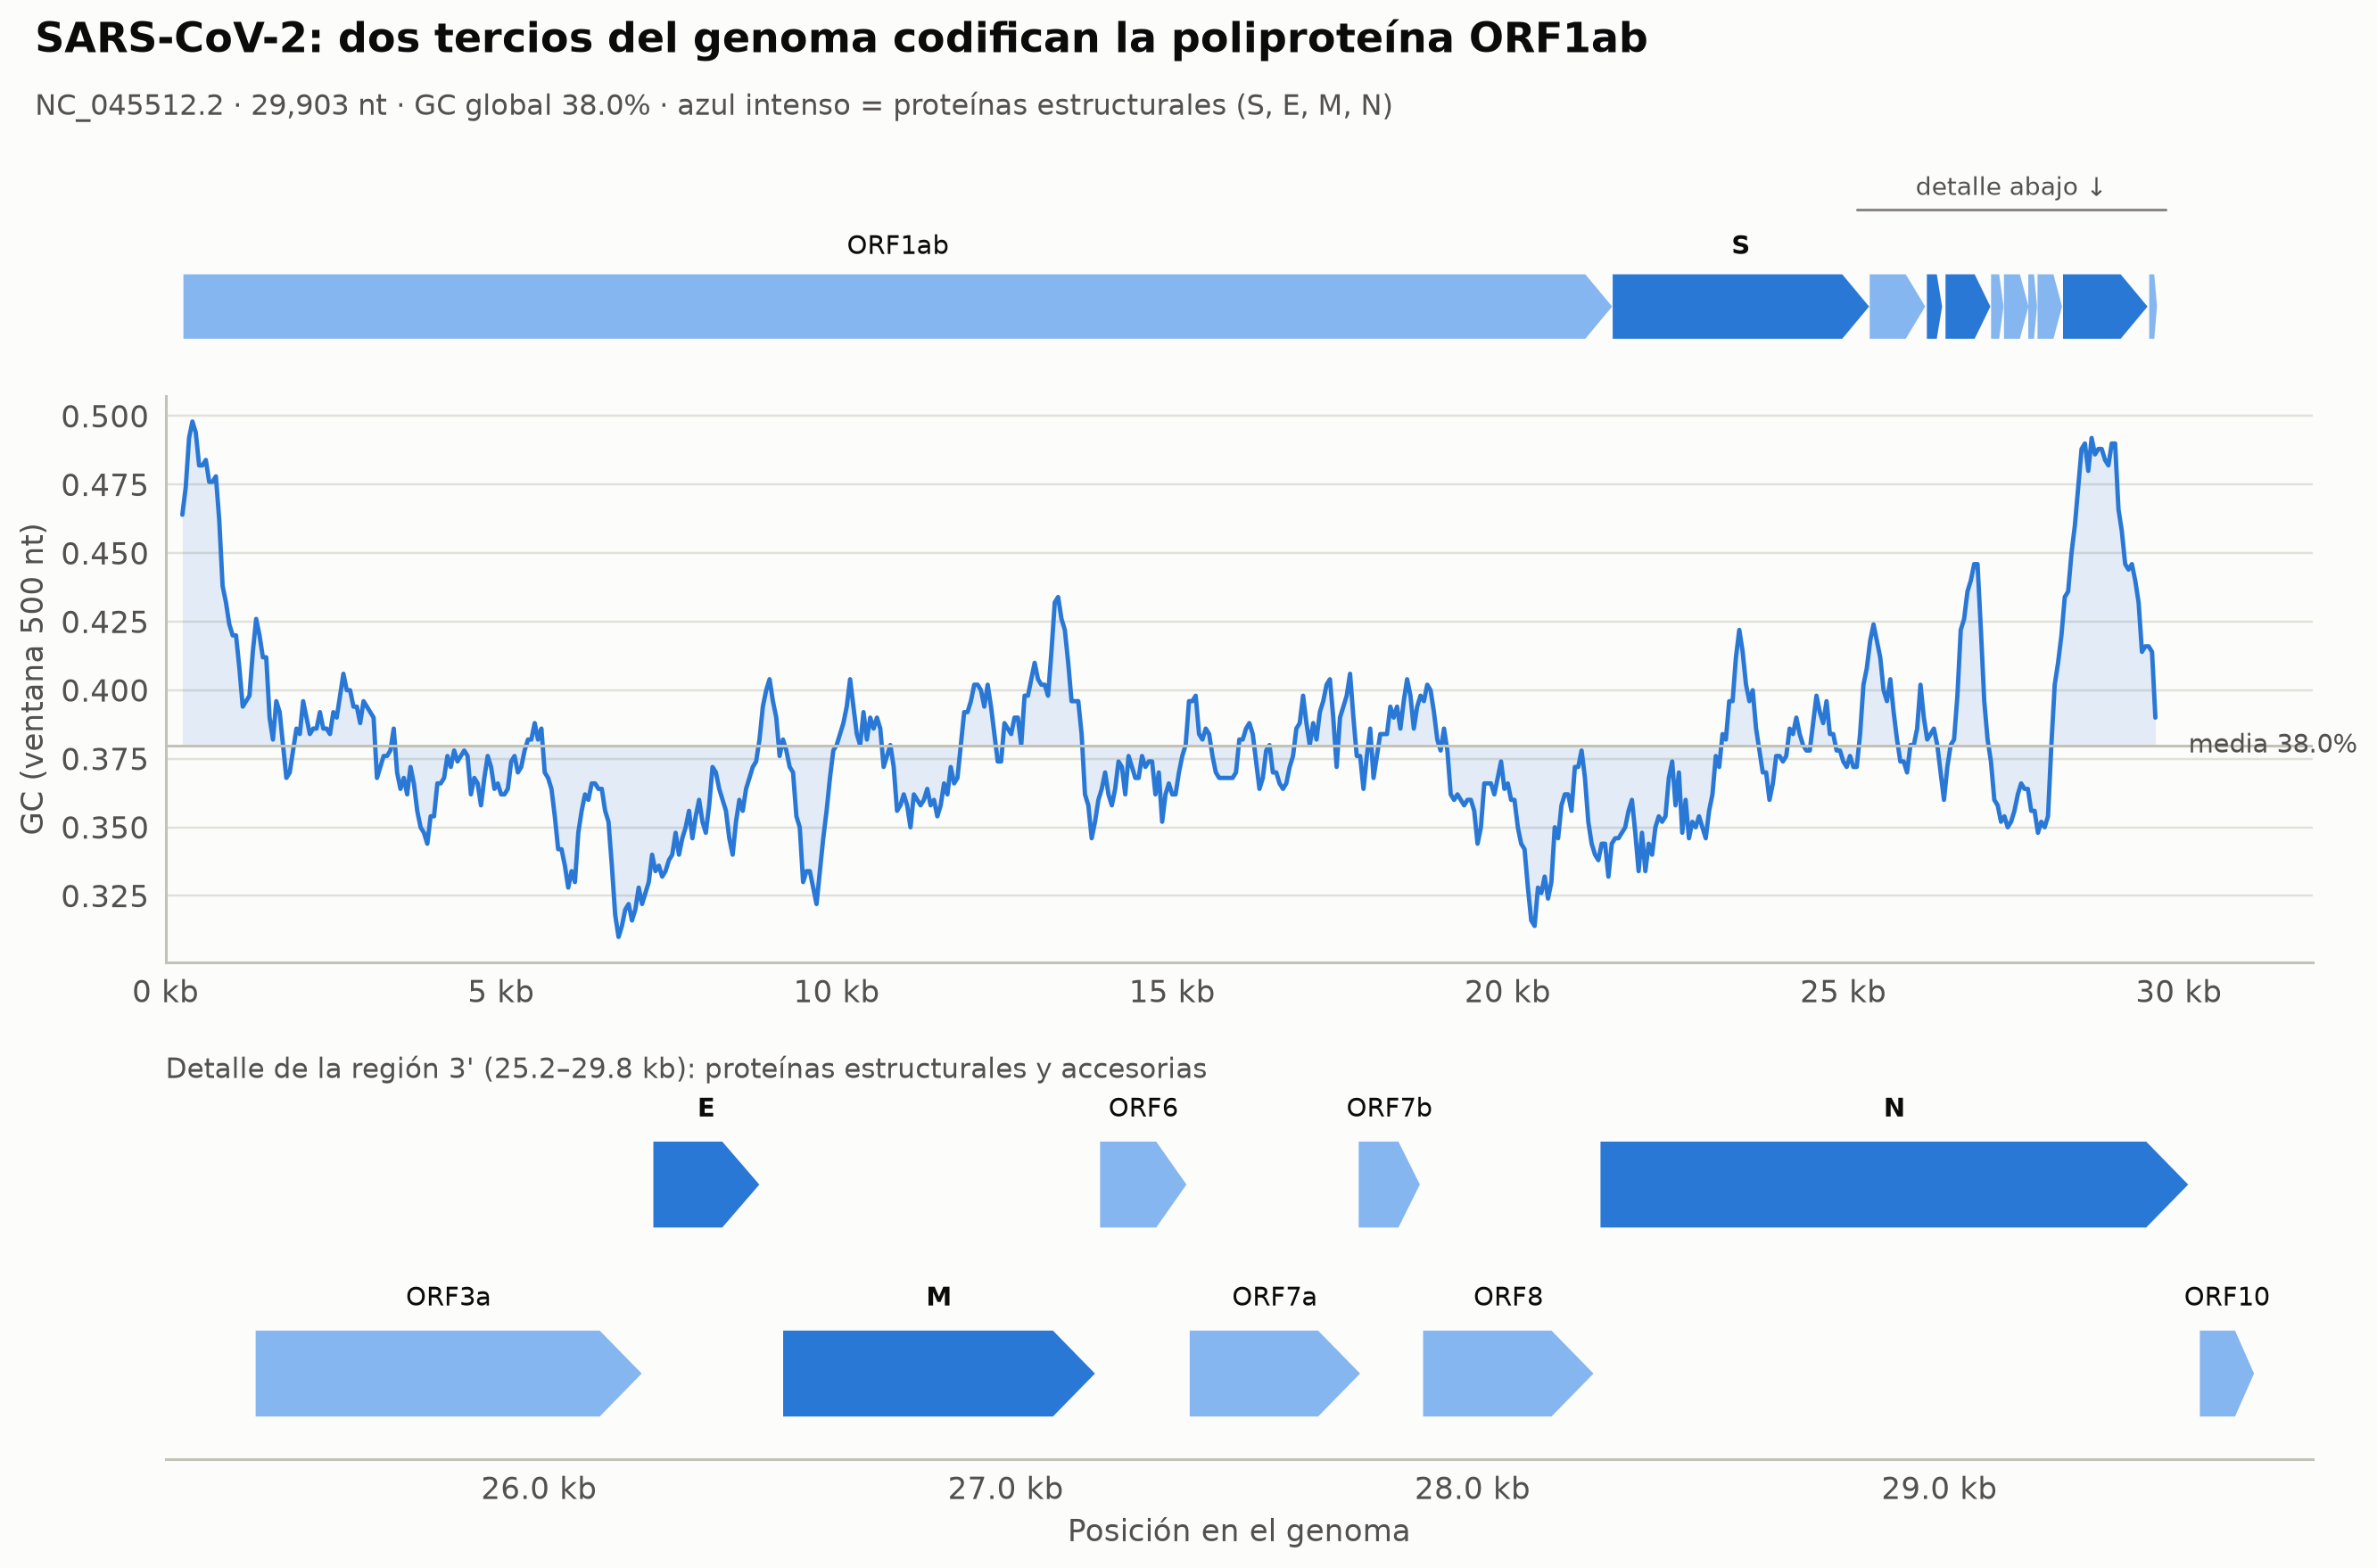

In [11]:
from matplotlib.patches import FancyArrow

seq_str = str(genome.seq)
arr = np.frombuffer(seq_str.encode(), dtype=np.uint8)
is_gc = ((arr == ord("G")) | (arr == ord("C"))).astype(int)
w = 500
csum = np.concatenate([[0], np.cumsum(is_gc)])
starts = np.arange(0, len(arr) - w + 1, 50)
gc_win = (csum[starts + w] - csum[starts]) / w
gc_global = is_gc.mean()

genes = cds.drop_duplicates("gene").reset_index(drop=True)      # la primera ORF1ab es pp1ab (2 partes)
STRUCTURAL = ("S", "E", "M", "N")

def draw_genes(ax, genes, two_lanes, min_label_nt=0):
    """Dibuja genes como flechas; los estructurales resaltados en azul."""
    for i, r in genes.iterrows():
        color = ec.BLUE if r["gene"] in STRUCTURAL else ec.SEQ_BLUE[3]
        lane = (i % 2) * 1.1 if two_lanes else 0
        length = r["end"] - r["start"]
        ax.add_patch(FancyArrow(r["start"], lane, length, 0, width=0.5, head_width=0.5,
                                head_length=min(length * 0.35, 90 if two_lanes else 400),
                                length_includes_head=True, color=color, lw=0))
        if length >= min_label_nt:
            ax.text(r["start"] + length / 2, lane + 0.36, r["gene"], ha="center", va="bottom", fontsize=9.5,
                    color=ec.INK, fontweight="bold" if r["gene"] in STRUCTURAL else "normal")
    ax.set_yticks([]); ax.grid(False)
    for sp in ax.spines.values(): sp.set_visible(False)

fig = plt.figure(figsize=(12, 7.2))
gs = fig.add_gridspec(3, 1, height_ratios=[0.8, 2.2, 1.6], hspace=0.08)
ax_g = fig.add_subplot(gs[0]); ax = fig.add_subplot(gs[1], sharex=ax_g); ax_z = fig.add_subplot(gs[2])

# Panel 1: genoma completo (sólo se etiquetan los genes largos)
draw_genes(ax_g, genes, two_lanes=False, min_label_nt=3000)
zoom = (25_200, 29_800)
ax_g.plot([zoom[0], zoom[1]], [0.75, 0.75], color=ec.MUTED, lw=1)
ax_g.text(np.mean(zoom), 0.82, "detalle abajo ↓", ha="center", va="bottom", fontsize=9, color=ec.INK_2)
ax_g.set_ylim(-0.4, 1.2)
ax_g.tick_params(labelbottom=False)

# Panel 2: contenido GC en ventanas
ax.fill_between(starts + w / 2, gc_global, gc_win, color=ec.BLUE, alpha=0.12, lw=0)
ax.plot(starts + w / 2, gc_win, color=ec.BLUE, lw=1.6)
ax.axhline(gc_global, color=ec.BASELINE, lw=1)
ax.text(len(arr), gc_global, f"  media {gc_global:.1%}", va="center", color=ec.INK_2, fontsize=9.5)
ax.set_ylabel("GC (ventana 500 nt)")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1000:.0f} kb"))
ax.set_xlim(0, len(arr) * 1.07)

# Panel 3: acercamiento a la región 3' con todos los genes etiquetados en dos carriles
region_genes = genes[genes["start"] >= zoom[0]].reset_index(drop=True)
draw_genes(ax_z, region_genes, two_lanes=True)
ax_z.set_xlim(*zoom); ax_z.set_ylim(-0.5, 1.9)
ax_z.spines["bottom"].set_visible(True)
ax_z.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1000:.1f} kb"))
ax_z.set_xlabel("Posición en el genoma")
ax_z.text(zoom[0], 1.85, "Detalle de la región 3' (25.2–29.8 kb): proteínas estructurales y accesorias",
          fontsize=10, color=ec.INK_2, va="top")

ec.fig_title(fig, "SARS-CoV-2: dos tercios del genoma codifican la poliproteína ORF1ab",
             f"{genome.id} · {len(genome):,} nt · GC global {gc_global:.1%} · azul intenso = proteínas estructurales (S, E, M, N)")
plt.show()

### 🖱️ Navegador genómico interactivo

La figura estática resume; ahora **explore**. En este mini navegador genómico puede arrastrar para hacer zoom en
cualquier región (pruebe con 26–29 kb, donde los genes están apretados), pasar el cursor sobre cada gen para ver
su producto y su tamaño, y hacer doble clic para volver a la vista completa. Ambos paneles comparten el eje x.

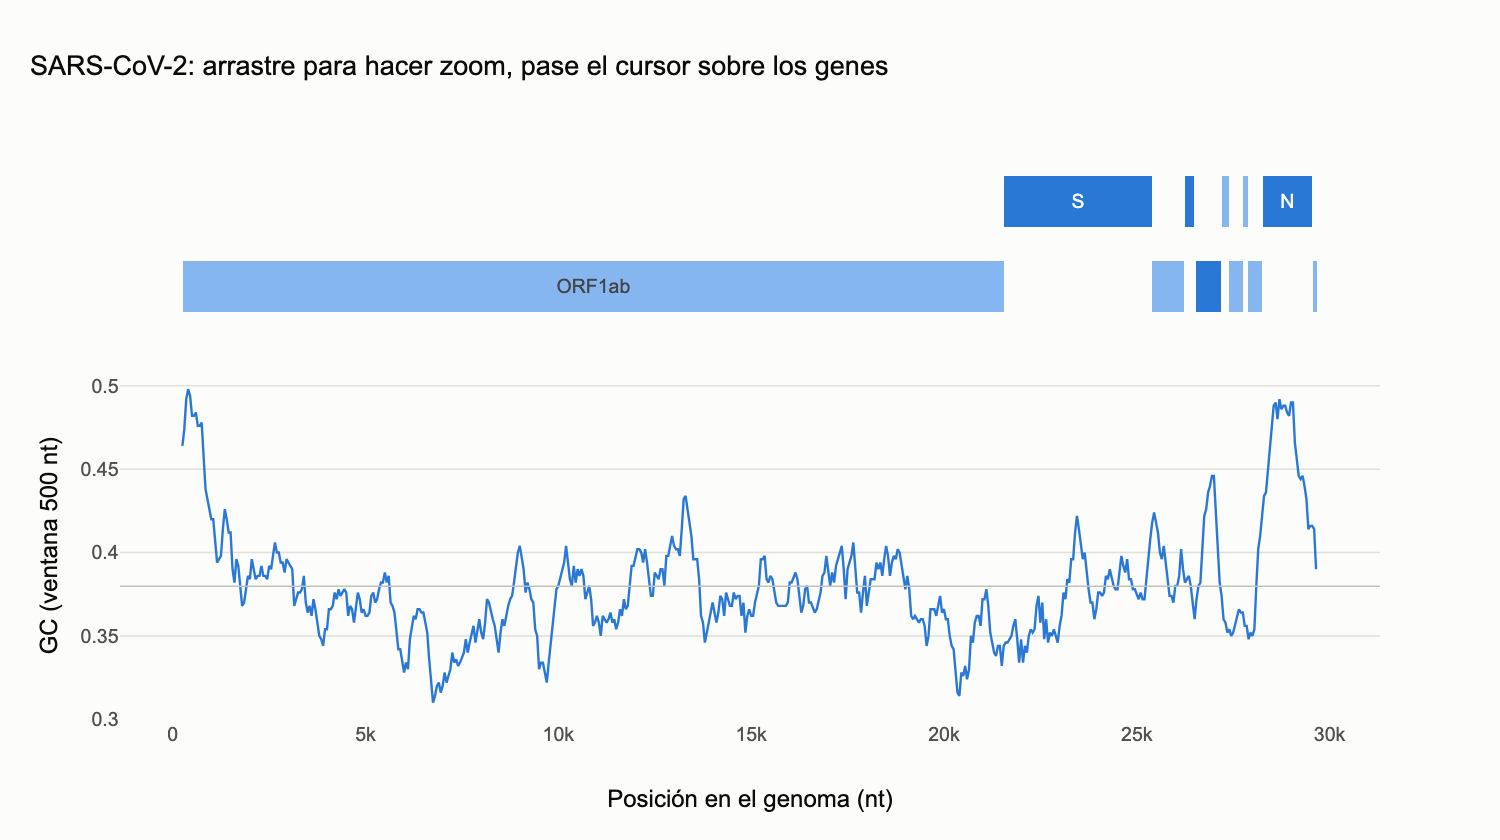

In [12]:
from plotly.subplots import make_subplots

figi = make_subplots(rows=2, cols=1, shared_xaxes=True, row_heights=[0.35, 0.65], vertical_spacing=0.06)
for i, r in genes.iterrows():
    figi.add_bar(x=[r["end"] - r["start"]], base=[r["start"]], y=[i % 2], orientation="h", width=0.6,
                 marker_color=ec.BLUE if r["gene"] in STRUCTURAL else ec.SEQ_BLUE[3], showlegend=False,
                 text=r["gene"] if r["length_nt"] >= 1000 else "", textposition="inside",
                 insidetextanchor="middle", textangle=0,
                 hovertemplate=(f"<b>{r['gene']}</b><br>{r['product']}<br>{r['start']:,}–{r['end']:,} nt"
                                f"<br>{r['length_nt']:,} nt ≈ {r['length_nt'] // 3 - 1:,} aa<extra></extra>"),
                 row=1, col=1)
figi.add_scatter(x=starts + w / 2, y=gc_win, mode="lines", line=dict(color=ec.BLUE, width=1.6),
                 hovertemplate="posición %{x:,.0f}<br>GC = %{y:.3f}<extra></extra>", showlegend=False, row=2, col=1)
figi.add_hline(y=gc_global, line_color=ec.BASELINE, line_width=1, row=2, col=1)
figi.update_yaxes(visible=False, range=[-0.6, 1.6], row=1, col=1)
figi.update_yaxes(title_text="GC (ventana 500 nt)", row=2, col=1)
figi.update_xaxes(title_text="Posición en el genoma (nt)", row=2, col=1)
figi.update_layout(title="SARS-CoV-2: arrastre para hacer zoom, pase el cursor sobre los genes", height=560,
                   barmode="overlay", bargap=0)
figi.show()

### Verificación: ¿nuestra traducción coincide con la proteína anotada?

Cada CDS del GenBank trae su proteína en el campo `translation`. Si extraemos la secuencia del gen y la traducimos
nosotros mismos, deberíamos obtener **exactamente** la misma proteína. Esto es un **control de calidad**: nunca
confíe ciegamente en un archivo, verifíquelo.

Compararemos dos maneras de extraer el gen:

* **Ingenua:** tomar todo lo que hay entre la coordenada de inicio y la de fin, y traducir.
* **Correcta:** `feat.extract()`, que respeta la estructura completa de la anotación (por ejemplo, si el gen está
  formado por varias partes o está en la hebra reversa).

> 🤔 **Antes de ejecutar, prediga:** ¿habrá algún gen en el que las dos maneras den resultados distintos? Recuerde
> la pista de la tabla anterior: la columna `parts`.

In [13]:
checks = []
for feat in genome.features:
    if feat.type != "CDS":
        continue
    annotated = feat.qualifiers["translation"][0]
    region = genome.seq[feat.location.start:feat.location.end]                                # ingenuo: inicio→fin
    naive = str(region[: len(region) // 3 * 3].translate(to_stop=True))
    proper = str(feat.extract(genome.seq).translate(to_stop=True))                            # respeta las partes
    checks.append({"gene": feat.qualifiers["gene"][0], "parts": len(feat.location.parts),
                   "aa_annotated": len(annotated),
                   "naive_ok": "✔" if naive == annotated else "✘",
                   "extract_ok": "✔" if proper == annotated else "✘"})
pd.DataFrame(checks)

,gene,parts,aa_annotated,naive_ok,extract_ok
0,ORF1ab,2,7096,✘,✔
1,ORF1ab,1,4405,✔,✔
2,S,1,1273,✔,✔
3,ORF3a,1,275,✔,✔
4,E,1,75,✔,✔
5,M,1,222,✔,✔
6,ORF6,1,61,✔,✔
7,ORF7a,1,121,✔,✔
8,ORF7b,1,43,✔,✔
9,ORF8,1,121,✔,✔


> 🎉 **Descubrimiento.** Para la poliproteína `pp1ab` la traducción ingenua falla (✘) pero `feat.extract()` acierta
> (✔). ¿Por qué? Porque el ribosoma, al llegar a una estructura de ARN en forma de nudo (*pseudoknot*) en la
> posición ~13 468, **retrocede un nucleótido** (*frameshift* ribosomal −1) y continúa en otro marco de lectura.
> El GenBank lo representa con una localización compuesta `join(266..13468, 13468..21555)`: la base 13 468 ¡se lee
> dos veces!
>
> Así el virus produce dos proteínas desde el mismo ARN: la corta (pp1a) cuando el ribosoma no salta, y la larga
> (pp1ab) cuando sí salta.

### Composición de aminoácidos de la proteína Spike (S)

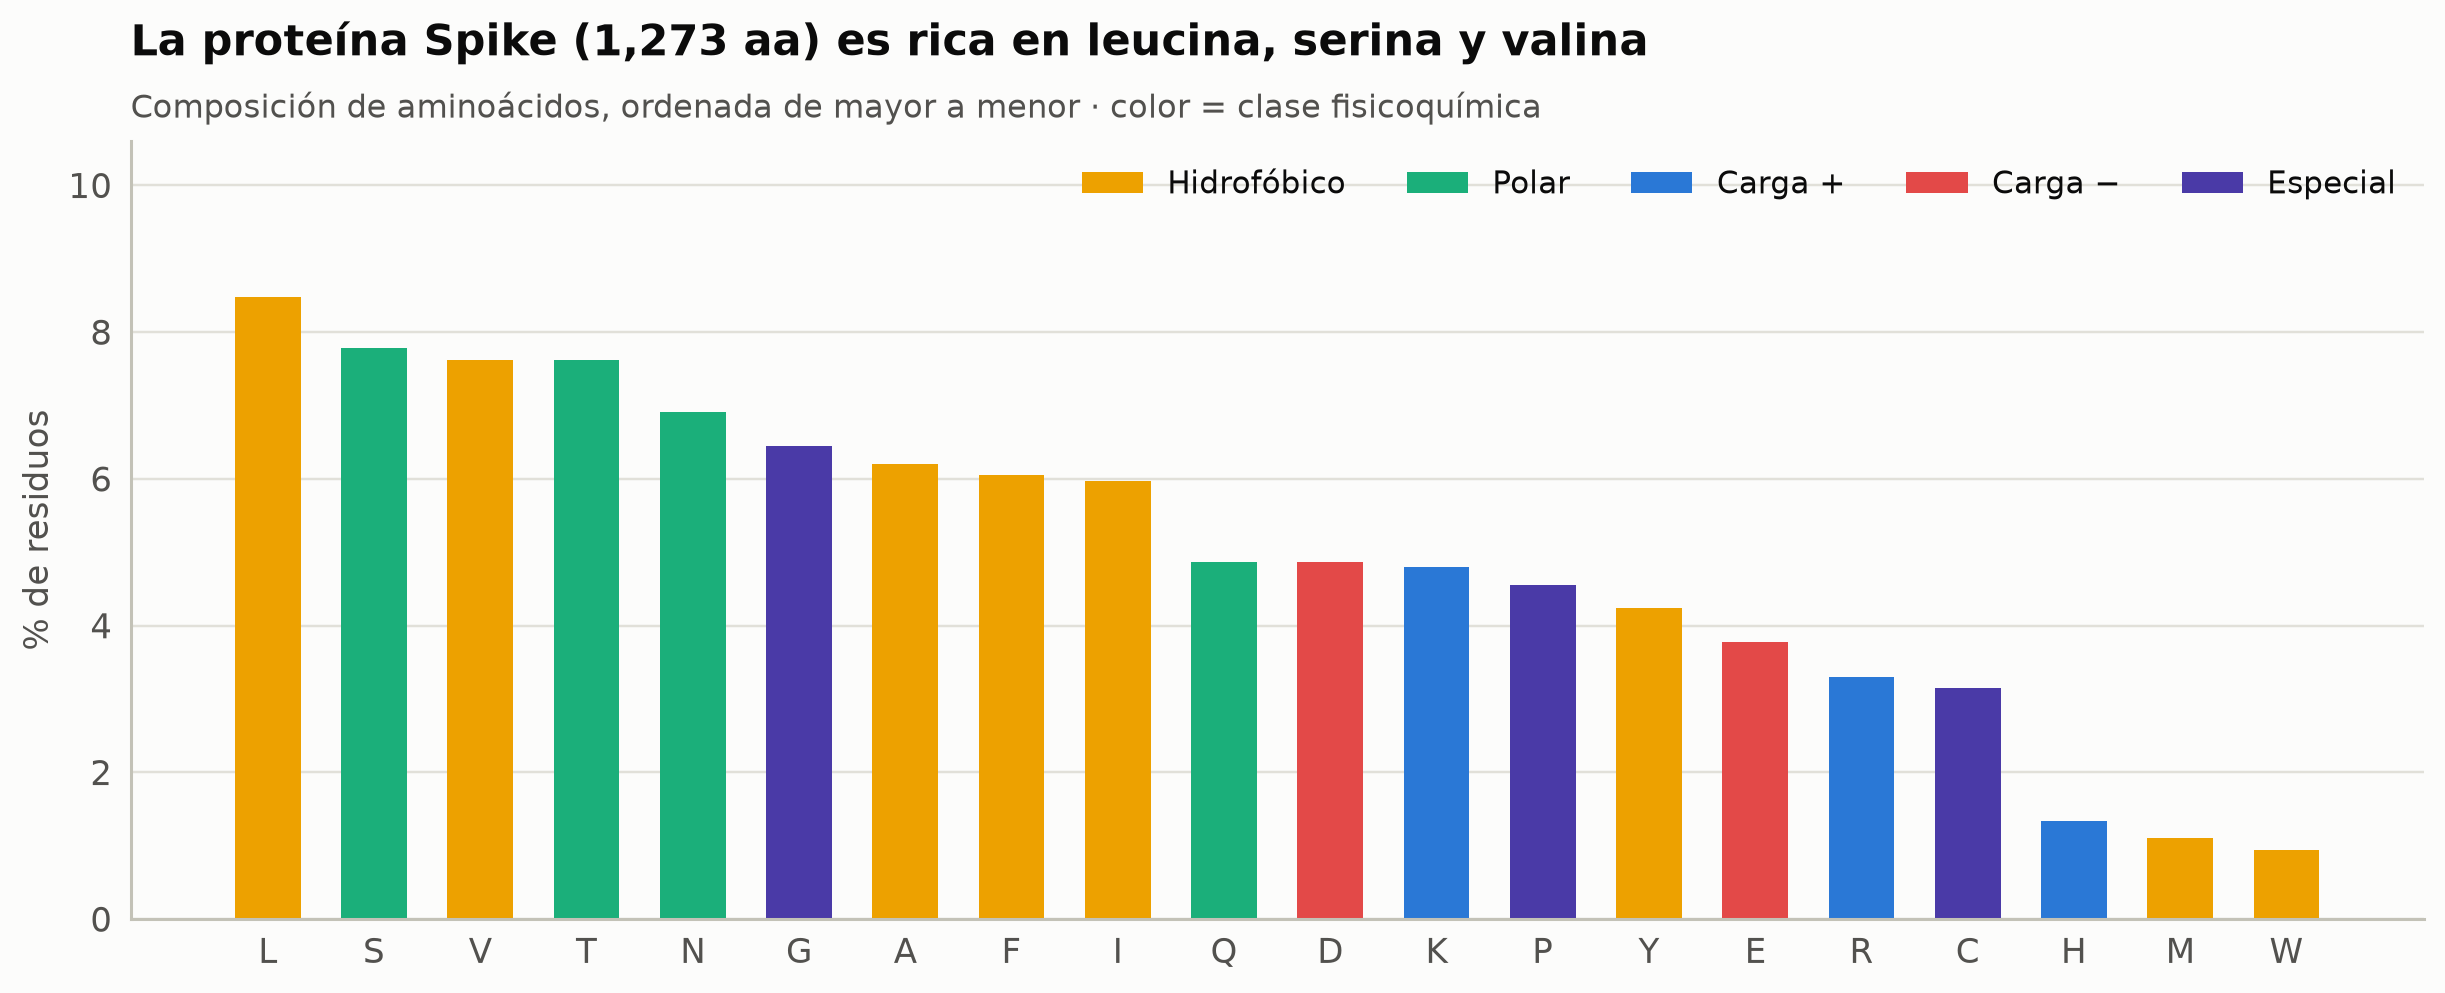

In [14]:
spike = next(f for f in genome.features if f.type == "CDS" and f.qualifiers.get("gene") == ["S"])
spike_prot = spike.qualifiers["translation"][0]
comp = pd.Series(Counter(spike_prot)).sort_values(ascending=False)
comp_pct = 100 * comp / comp.sum()

fig, ax = plt.subplots(figsize=(11, 4.4))
colors = [class_color[aa_class[a]] for a in comp_pct.index]
bars = ax.bar(comp_pct.index, comp_pct.values, color=colors, width=0.62)
ax.set_ylabel("% de residuos")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for k, c in class_color.items() if k != "Stop"]
ax.legend(handles, [k for k in class_color if k != "Stop"], ncol=5, loc="upper right")
ax.set_ylim(0, comp_pct.max() * 1.25)
aa_name = {"L": "leucina", "S": "serina", "V": "valina", "T": "treonina", "N": "asparagina", "G": "glicina",
           "A": "alanina", "F": "fenilalanina", "I": "isoleucina"}
top3 = [aa_name.get(a, three[a]) for a in comp_pct.index[:3]]
ec.title(ax, f"La proteína Spike ({len(spike_prot):,} aa) es rica en {top3[0]}, {top3[1]} y {top3[2]}",
         "Composición de aminoácidos, ordenada de mayor a menor · color = clase fisicoquímica")
plt.show()

## 7. 🧪 Experimento: BLAST desde la línea de comandos

**BLAST** (*Basic Local Alignment Search Tool*) busca secuencias parecidas a una consulta dentro de una base de
datos. Lo estudiaremos a fondo en la Lección 3.4; hoy lo usamos como ejemplo de **herramienta de línea de comandos**.

Piense en el buscador de un libro enorme que tolera errores de tipeo: usted escribe una frase con algunas letras
equivocadas y el buscador le devuelve en qué páginas aparece algo parecido, y cuán parecido es. BLAST hace eso con
secuencias. Su truco para ser rápido es buscar primero **"semillas"**: palabras cortas (11 nt por defecto en
`blastn`) que coincidan **exactamente**; alrededor de cada semilla intenta extender el alineamiento hacia ambos lados,
tolerando algunas diferencias, mientras el puntaje siga siendo bueno.

> 🤔 **Antes de ejecutar, prediga:** con 15 mutaciones en 300 nt (una cada 20 nt en promedio), ¿habrá suficientes
> tramos de 11 nt sin mutaciones para que BLAST encuentre una semilla? ¿Qué % de identidad reportará?

En Colab (Ubuntu) se instala con el gestor de paquetes `apt`. El experimento:

1. Construimos una **base de datos** BLAST con el genoma de SARS-CoV-2.
2. Tomamos un fragmento de 300 nt del gen S e introducimos **mutaciones al azar** (5 %).
3. Buscamos el fragmento mutado y vemos si BLAST lo ubica en el lugar correcto.

In [15]:
import shutil, subprocess

if shutil.which("blastn") is None and IN_COLAB:
    !apt-get -qq install -y ncbi-blast+ > /dev/null
HAS_BLAST = shutil.which("blastn") is not None
print("BLAST disponible:", HAS_BLAST)
if HAS_BLAST:
    !blastn -version
else:
    print("⚠️ Ejecute este notebook en Colab para la parte de línea de comandos.")

BLAST disponible: False
⚠️ Ejecute este notebook en Colab para la parte de línea de comandos.


In [16]:
rng = np.random.default_rng(3)
s_start = int(spike.location.start)
true_start = s_start + 1500                        # posición real (0-based) del fragmento
fragment = list(str(genome.seq[true_start:true_start + 300]))
mut_pos = rng.choice(300, size=15, replace=False)  # 5 % de mutaciones
for p in mut_pos:
    fragment[p] = rng.choice([b for b in "ACGT" if b != fragment[p]])
SeqIO.write([genome], "sarscov2.fasta", "fasta")
SeqIO.write([SeqRecord(Seq("".join(fragment)), id="query_S_mut")], "query.fasta", "fasta")
print(f"Fragmento real: {true_start + 1:,}–{true_start + 300:,} (1-based) con 15 mutaciones")

Fragmento real: 23,063–23,362 (1-based) con 15 mutaciones


In [17]:
if HAS_BLAST:
    !makeblastdb -in sarscov2.fasta -dbtype nucl -out sarscov2_db > /dev/null
    !blastn -query query.fasta -db sarscov2_db -outfmt "6 qseqid sseqid pident length mismatch gapopen qstart qend sstart send evalue bitscore" -out hits.tsv
    cols = ["qseqid", "sseqid", "pident", "length", "mismatch", "gapopen",
            "qstart", "qend", "sstart", "send", "evalue", "bitscore"]
    hits = pd.read_csv("hits.tsv", sep="\t", names=cols)
    display(hits)

> 🔎 **Lectura de la tabla** (formato tabular `-outfmt 6`, el más usado en la práctica):
>
> | Columna | Significado |
> |---|---|
> | `pident` | % de identidad en el alineamiento (esperamos ≈ 95 %) |
> | `length`, `mismatch`, `gapopen` | longitud alineada, bases distintas, huecos abiertos |
> | `sstart`, `send` | dónde cae en el genoma (compare con la posición real) |
> | `evalue` | cuántos aciertos así de buenos esperaríamos **por azar** — cuanto más pequeño, mejor |
> | `bitscore` | puntaje normalizado del alineamiento |

### Opcional: `conda` en Colab

Muchas herramientas bioinformáticas se distribuyen por **Bioconda**. En Colab se activa con `condacolab`:

```python
%pip install -q condacolab
import condacolab
condacolab.install()        # ⚠️ REINICIA el entorno: al terminar, continúe desde la celda siguiente
```

Después: `!mamba install -q -c bioconda -c conda-forge samtools bwa`. Úselo sólo cuando `apt` o `pip` no tengan la
herramienta, porque el reinicio borra todas las variables. En el curso lo indicaremos en la **primera celda** de
las lecciones que lo necesiten.

## ✍️ Ejercicios

**Ejercicio 1 — Otro código genético.** Las mitocondrias de vertebrados usan la tabla 2 del NCBI. Traduzca
`gene` con `table=2` y compare con la tabla estándar. ¿Qué codón cambió de significado?

**Ejercicio 2 — La proteína N.** Extraiga la proteína de la nucleocápside (gen `N`) y calcule su **punto
isoeléctrico** y **peso molecular** con `Bio.SeqUtils.ProtParam.ProteinAnalysis`. ¿Por qué tiene sentido que sea
una proteína básica (pI alto) si se une al ARN viral?

**Ejercicio 3 — Sensibilidad de BLAST.** Repita el experimento de BLAST con 10 %, 20 % y 30 % de mutaciones.
¿A partir de qué divergencia BLAST deja de encontrar el fragmento? (Sólo en Colab.)

**Ejercicio 4 — Otro virus.** Descargue el genoma de referencia de SARS-CoV-1 (`NC_004718.3`) y compare su
contenido GC y el número de CDS con los de SARS-CoV-2.

In [18]:
#@title 🔑 Solución — Ejercicio 1 { display-mode: "form" }
print("Estándar     :", gene.translate(table=1))
print("Mitocondrial :", gene.translate(table=2))
print("En la tabla 2, AGA/AGG son stop y TGA codifica triptófano (W).")

Estándar     : MAIVMGR*KGAR*
Mitocondrial : MAIVMGRWKGAR*
En la tabla 2, AGA/AGG son stop y TGA codifica triptófano (W).


In [19]:
#@title 🔑 Solución — Ejercicio 2 { display-mode: "form" }
from Bio.SeqUtils.ProtParam import ProteinAnalysis
n_feat = next(f for f in genome.features if f.type == "CDS" and f.qualifiers.get("gene") == ["N"])
pa = ProteinAnalysis(n_feat.qualifiers["translation"][0])
print(f"Proteína N: {pa.length} aa · peso = {pa.molecular_weight()/1000:.1f} kDa · pI = {pa.isoelectric_point():.2f}")
print("pI > 7 → carga neta positiva a pH fisiológico → se une al ARN (cargado negativamente).")

Proteína N: 419 aa · peso = 45.6 kDa · pI = 10.07
pI > 7 → carga neta positiva a pH fisiológico → se une al ARN (cargado negativamente).


In [20]:
#@title 🔑 Solución — Ejercicio 3 { display-mode: "form" }
if HAS_BLAST:
    for rate in [0.10, 0.20, 0.30]:
        frag = list(str(genome.seq[true_start:true_start + 300]))
        for p in rng.choice(300, size=int(300 * rate), replace=False):
            frag[p] = rng.choice([b for b in "ACGT" if b != frag[p]])
        SeqIO.write([SeqRecord(Seq("".join(frag)), id=f"mut{rate}")], "q.fasta", "fasta")
        out = subprocess.run(["blastn", "-query", "q.fasta", "-db", "sarscov2_db", "-outfmt", "6 pident length evalue"],
                             capture_output=True, text=True).stdout.strip()
        print(f"{rate:.0%} mutaciones →", out.splitlines()[0] if out else "sin hits")

In [21]:
#@title 🔑 Solución — Ejercicio 4 { display-mode: "form" }
try:
    with Entrez.efetch(db="nuccore", id="NC_004718.3", rettype="gb", retmode="text") as h:
        sars1 = SeqIO.read(h, "genbank")
    for rec in (genome, sars1):
        n_cds = sum(f.type == "CDS" for f in rec.features)
        gc = (rec.seq.count("G") + rec.seq.count("C")) / len(rec)
        print(f"{rec.id}: {len(rec):,} nt · GC = {gc:.1%} · CDS = {n_cds}")
except Exception as err:
    print("No se pudo descargar:", err)

NC_045512.2: 29,903 nt · GC = 38.0% · CDS = 12
NC_004718.3: 29,751 nt · GC = 40.8% · CDS = 15


## 📌 Resumen

* `Seq` sabe biología: complemento, complemento reverso, transcripción y traducción (con distintos códigos genéticos).
* El código genético usa **tripletes** porque $4^2 = 16 < 21 \le 4^3 = 64$; por eso es **degenerado**.
* Toda secuencia tiene **seis marcos de lectura**.
* `SeqIO` lee/escribe FASTA, GenBank y muchos más; `Entrez` descarga datos del NCBI.
* **Verifique siempre las anotaciones**: así descubrimos el *frameshift* ribosomal de ORF1ab.
* En Colab, `!` ejecuta la terminal, `apt` instala programas y `%pip` paquetes de Python.
* El ribosoma lee el ARNm de tres en tres; la **rueda del código** y el **navegador genómico** interactivos son
  herramientas para explorar, no sólo para mirar.

**Próxima lección (0.3):** reproducibilidad — semillas aleatorias, versiones, huellas digitales de archivos y Git.

## 📚 Para profundizar

* Cock, P. J. A. *et al.* (2009). Biopython: freely available Python tools for computational molecular biology
  and bioinformatics. *Bioinformatics* 25(11): 1422–1423.
* *Biopython Tutorial and Cookbook* (biopython.org), capítulos 3–5 y 9.
* Wu, F. *et al.* (2020). A new coronavirus associated with human respiratory disease in China. *Nature* 579: 265–269.

---

<sub>**Bioinformática Práctica** · © 2026 Juvenal Yosa, PhD · [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · Código bajo licencia MIT ·
Desarrollado con **Claude** (Anthropic) como copiloto.</sub>

[![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai)